# 과제 - 신경망을 이용한 손글씨 숫자 인식



## 1. 환경설정



In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요 (저장소 클론 후 경로·모듈 로드)
# 주의: Colab에서는 GitHub 저장소 URL과 Personal Access Token을 반드시 입력해야 합니다.
import os
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    from getpass import getpass

    git_url = input("GitHub 저장소 URL (예: github.com/USERNAME/mnist-lab.git): ").strip()
    token = getpass("GitHub Personal Access Token (private 저장소인 경우): ")

    # URL 마지막 경로를 저장소 폴더명으로 사용합니다. (예: .../mnist-lab.git -> mnist-lab)
    repo_name = Path(git_url.rstrip("/")).name
    if repo_name.endswith(".git"):
        repo_name = repo_name[:-4]

    !git clone https://{token}@{git_url}
    os.chdir(repo_name)
    sys.path.insert(0, str(Path.cwd() / "src"))
else:
    sys.path.insert(0, "./src")


## 2. 데이터 로드

In [2]:
from data import load_mnist

(x_train, y_train), (x_test, y_test) = load_mnist()
print('Train:', x_train.shape, y_train.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (60000, 784) (60000,)
Test: (10000, 784) (10000,)


## 3. 구현 및 테스트 통과 확인

`src/` 아래 역할별 파일의 **TODO**를 순서대로 구현한 뒤 아래 셀을 실행하세요.
- 주요 구현 파일: `activations.py`, `layers.py`, `losses.py`, `optimizers.py`, `network.py`, `training.py`
- 구현 파일은 역할별 모듈을 직접 import합니다. 예: `from network import NeuralNetwork`
- 개발 순서: 과제 안내문 참조
- 테스트: `tests/` 아래의 단계별 단위 테스트를 필요한 파일부터 실행합니다. 처음에는 전체 테스트보다 맡은 부분의 테스트 파일을 먼저 실행하세요.
    - ReLU만 확인: `TEST_TARGET = "tests/test_relu.py"`
    - 파일 안의 일부 테스트만 확인: `PYTEST_KEYWORD = "backward"`
    - 전체 테스트 확인: `TEST_TARGET = "tests/"`

In [3]:
import subprocess
import sys
from pathlib import Path

# Colab/로컬 모두 현재 노트북 실행 위치를 저장소 루트로 사용합니다.
repo_dir = Path.cwd()

# 처음에는 자신이 구현 중인 부분의 테스트 파일만 실행하세요.
# 예: tests/test_relu.py, tests/test_affine.py, tests/test_training.py
TEST_TARGET = "tests/test_relu.py"

# 특정 이름이 들어간 테스트만 실행하고 싶을 때 사용합니다.
# 예: "backward". 전체 파일을 실행하려면 빈 문자열로 둡니다.
PYTEST_KEYWORD = ""

cmd = [sys.executable, "-m", "pytest", TEST_TARGET, "-v"]
if PYTEST_KEYWORD:
    cmd.extend(["-k", PYTEST_KEYWORD])

print("실행 경로:", repo_dir)
print("실행 명령:", " ".join(cmd))
result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    cwd=str(repo_dir)
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
if result.returncode == 0:
    print("\n선택한 테스트를 통과했습니다.")
else:
    print("\n선택한 테스트 중 실패가 있습니다.")


실행 경로: c:\week13-team-07-mnist-lab
실행 명령: c:\Users\82103\anaconda3\envs\mnist-nn\python.exe -m pytest tests/test_relu.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\82103\anaconda3\envs\mnist-nn\python.exe
cachedir: .pytest_cache
rootdir: c:\week13-team-07-mnist-lab
collecting ... collected 3 items

tests/test_relu.py::TestReLU::test_relu_forward_positive PASSED          [ 33%]
tests/test_relu.py::TestReLU::test_relu_forward_negative_zero PASSED     [ 66%]
tests/test_relu.py::TestReLU::test_relu_backward PASSED                  [100%]

============================== 3 passed in 0.17s ==============================


선택한 테스트를 통과했습니다.


## 4. 모델·옵티마이저 생성 및 학습

In [4]:
from network import NeuralNetwork
from optimizers import Adam
from training import train

model = NeuralNetwork(use_batchnorm=True, use_dropout=True)  # BatchNorm, Dropout 필수
optimizer = Adam(lr=0.026677926407289915)

loss_history = train(model, optimizer, x_train, y_train, epochs=64, batch_size=100)

## 5. 평가 및 손실 커브

Train Accuracy: 99.87%
Test Accuracy: 98.60%
Total Params: 537,354


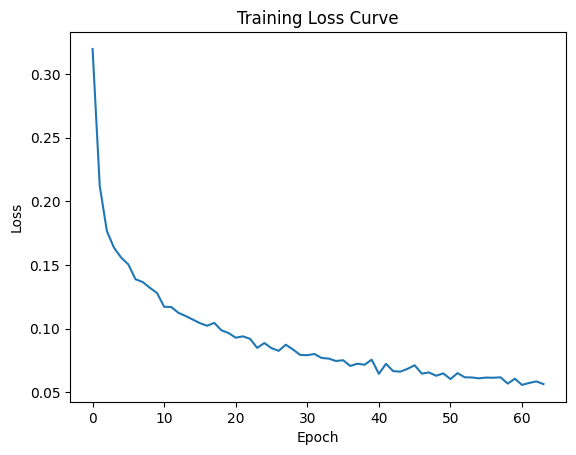

In [5]:
from training import evaluate, plot_loss_history

# acc, n_params = evaluate(model, x_test, y_test)

final_test_acc, n_params = evaluate(model, x_test, y_test)
final_train_acc, _ = evaluate(model, x_train, y_train)

# print(f'Test Accuracy: {acc:.2f}%')
print(f"Train Accuracy: {final_train_acc:.2f}%")
print(f"Test Accuracy: {final_test_acc:.2f}%")
print(f'Total Params: {n_params:,}')

plot_loss_history(loss_history)

In [6]:
# 모델 저장

import os
import pickle
from datetime import datetime

os.makedirs("saved_models", exist_ok=True)

current_epoch = 1500
model_name = "1500ep-mj"   # 원하는 이름으로 변경 가능

checkpoint = {
    "model_params": {k: v.copy() for k, v in model.params.items()},
    "optimizer_state": {
        "m": {k: v.copy() for k, v in optimizer.m.items()},
        "v": {k: v.copy() for k, v in optimizer.v.items()},
        "t": optimizer.t,
        "lr": optimizer.lr,
    },
    "train_state": {
        "epoch": current_epoch,
        "loss_history": list(loss_history),
    },
    "model_config": {
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_ratio": 0.5,
    },
    "metrics": {
        "final_loss": float(loss_history[-1]) if len(loss_history) > 0 else None,
        "final_train_acc": float(final_train_acc),
        "final_test_acc": float(final_test_acc),
    },
    "meta": {
        "saved_at": datetime.now().isoformat(timespec="seconds"),
        "optimizer": "Adam",
    },
}

checkpoint_path = f"saved_models/{model_name}.pkl"

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print(f"saved: {checkpoint_path}")

saved: saved_models/1500ep-mj.pkl


In [39]:
# 저장된 모델 불러오기

import pickle
from network import NeuralNetwork
from optimizers import Adam

checkpoint_path = "saved_models/1500ep-mj.pkl"

with open(checkpoint_path, "rb") as f:
    checkpoint = pickle.load(f)

config = checkpoint["model_config"]

model = NeuralNetwork(
    use_batchnorm=config["use_batchnorm"],
    use_dropout=config["use_dropout"],
    dropout_ratio=config["dropout_ratio"],
)

optimizer = Adam(lr=checkpoint["optimizer_state"]["lr"])

for key in model.params:
    model.params[key][...] = checkpoint["model_params"][key]

optimizer.m = {k: v.copy() for k, v in checkpoint["optimizer_state"]["m"].items()}
optimizer.v = {k: v.copy() for k, v in checkpoint["optimizer_state"]["v"].items()}
optimizer.t = checkpoint["optimizer_state"]["t"]

current_epoch = checkpoint["train_state"]["epoch"]
loss_history = checkpoint["train_state"]["loss_history"]

print(f"loaded: {checkpoint_path}")
print(f"epoch: {current_epoch}")
print(f"final_test_acc: {checkpoint['metrics'].get('final_test_acc')}")

loaded: saved_models/1500ep-mj.pkl
epoch: 1500
final_test_acc: 93.8


In [ ]:
# 이어서 학습

additional_epochs = 100
new_loss_history = train(model, optimizer, x_train, y_train, epochs=additional_epochs, batch_size=100)

loss_history.extend(new_loss_history)
current_epoch += additional_epochs

In [7]:
# 저장된 모델들 확인

import os
import glob
import pickle
import pandas as pd

model_files = sorted(glob.glob("saved_models/*.pkl"))

rows = []

for path in model_files:
    with open(path, "rb") as f:
        checkpoint = pickle.load(f)

    metrics = checkpoint.get("metrics", {})
    train_state = checkpoint.get("train_state", {})
    model_config = checkpoint.get("model_config", {})
    meta = checkpoint.get("meta", {})

    rows.append({
        "file_name": os.path.basename(path),
        "epoch": train_state.get("epoch"),
        "final_loss": metrics.get("final_loss"),
        "final_train_acc": metrics.get("final_train_acc"),
        "final_test_acc": metrics.get("final_test_acc"),
        "optimizer": meta.get("optimizer"),
        "use_batchnorm": model_config.get("use_batchnorm"),
        "use_dropout": model_config.get("use_dropout"),
        "dropout_ratio": model_config.get("dropout_ratio"),
    })

df = pd.DataFrame(rows)
display(df)

ModuleNotFoundError: No module named 'pandas'

In [45]:
# 제외할 파일명 지정

import glob
import os

excluded_files = {"1500ep-mj.pkl"}

model_files = [
    path for path in sorted(glob.glob("saved_models/*.pkl"))
    if os.path.basename(path) not in excluded_files
]

print([os.path.basename(path) for path in model_files])

['64ep-yk.pkl']


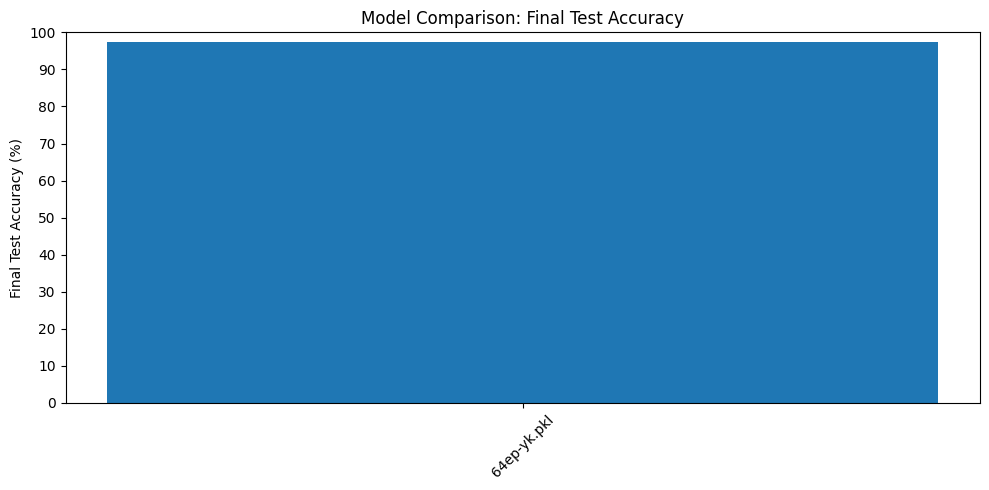

In [47]:
# 최종 테스트 정확도 막대그래프

import matplotlib.pyplot as plt

plot_df = df.dropna(subset=["final_test_acc"]).copy()
plot_df = plot_df[~plot_df["file_name"].isin(excluded_files)]

plt.figure(figsize=(10, 5))
plt.bar(plot_df["file_name"], plot_df["final_test_acc"])
plt.xticks(rotation=45)
plt.yticks(range(0, 101, 10))
plt.ylim(0, 100)
plt.ylabel("Final Test Accuracy (%)")
plt.title("Model Comparison: Final Test Accuracy")
plt.tight_layout()
plt.show()

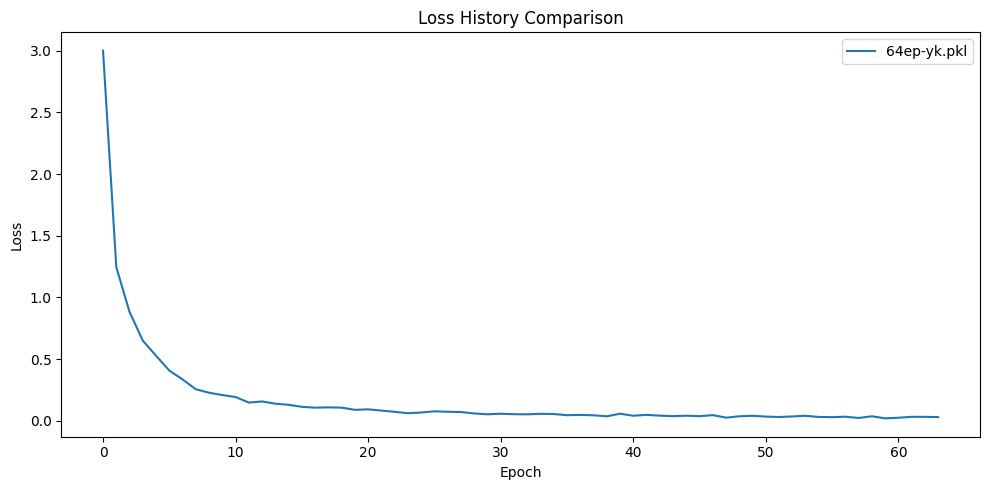

In [49]:
# 최종 loss 막대그래프

import os
import glob
import pickle
import matplotlib.pyplot as plt

model_files = [
    path for path in sorted(glob.glob("saved_models/*.pkl"))
    if os.path.basename(path) not in excluded_files
]

plt.figure(figsize=(10, 5))

for path in model_files:
    with open(path, "rb") as f:
        checkpoint = pickle.load(f)

    loss_history = checkpoint.get("train_state", {}).get("loss_history", [])
    if len(loss_history) > 0:
        plt.plot(loss_history, label=os.path.basename(path))

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss History Comparison")
plt.legend()
plt.tight_layout()
plt.show()